# Estimation de la Value-at-Risk par la Théorie des Valeurs Extrêmes

## Application au portefeuille [Fotamana]

Méthodes implémentées :
- TVE (POT)
- TVE-GARCH

Cours : Mesures des Risques Financiers et Modélisation de la Volatilité

In [1]:
# 1. IMPORTATIONS
# LIBRAIRIES GENERALES
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis
from scipy.stats import genpareto

# STATISTIQUES EXTREMES
from scipy.stats import genpareto
from scipy import stats

# MODELE GARCH
#from arch import arch_model

plt.style.use("seaborn-v0_8")


In [8]:
data = pd.read_excel("onglets\Data_set.xlsx", index_col=0, parse_dates=True)
print(data.columns)
print(data.columns[:3])
print(data.columns[3:6])
print(data.columns[6:9])
print(data.columns[9:12])
print(data.columns[12:])


Index(['LVMH', 'OREP', 'PRTP', 'AirbusSE', 'Safran SA', 'Air Liquide SA',
       'BOLL_Price', 'ENGIE_Price', 'TTEF_Price', 'DSY (Dassault)',
       'STMPA (STMicroelectornics)', 'Capegimini', 'BNPP', 'CAGR', 'AXA SA'],
      dtype='object')
Index(['LVMH', 'OREP', 'PRTP'], dtype='object')
Index(['AirbusSE', 'Safran SA', 'Air Liquide SA'], dtype='object')
Index(['BOLL_Price', 'ENGIE_Price', 'TTEF_Price'], dtype='object')
Index(['DSY (Dassault)', 'STMPA (STMicroelectornics)', 'Capegimini'], dtype='object')
Index(['BNPP', 'CAGR', 'AXA SA'], dtype='object')


In [ ]:
# 2. CHARGEMENT ET PREPARATION DES DONNEES

print(data.info())
data.head()

Index(['LVMH', 'OREP', 'PRTP', 'AirbusSE', 'Safran SA', 'Air Liquide SA',
       'BOLL_Price', 'ENGIE_Price', 'TTEF_Price', 'DSY (Dassault)',
       'STMPA (STMicroelectornics)', 'Capegimini', 'BNPP', 'CAGR', 'AXA SA'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1303 entries, 2026-02-20 to 2021-01-22
Data columns (total 15 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   LVMH                        1303 non-null   float64
 1   OREP                        1303 non-null   float64
 2   PRTP                        1303 non-null   float64
 3   AirbusSE                    1303 non-null   float64
 4   Safran SA                   1303 non-null   float64
 5   Air Liquide SA              1303 non-null   float64
 6   BOLL_Price                  1303 non-null   float64
 7   ENGIE_Price                 1303 non-null   float64
 8   TTEF_Price                  1303 non-null   float64
 9   D

,LVMH,OREP,PRTP,AirbusSE,Safran SA,Air Liquide SA,BOLL_Price,ENGIE_Price,TTEF_Price,DSY (Dassault),STMPA (STMicroelectornics),Capegimini,BNPP,CAGR,AXA SA
Date,,,,,,,,,,,,,,,
2026-02-20,554.7,401.15,278.00,189.74,346.4,175.56,4.88,26.30,65.44,17.43,28.56,104.50,94.73,18.57,39.80
2026-02-19,531.5,395.00,275.50,187.10,342.1,167.52,4.85,26.42,66.53,17.54,28.30,103.95,93.84,18.25,39.12
2026-02-18,533.9,394.55,276.35,200.65,347.2,167.70,4.79,26.82,65.34,17.22,28.78,105.30,94.25,18.30,38.75
2026-02-17,527.7,390.45,272.90,196.50,340.9,170.26,4.70,26.54,64.57,16.73,27.72,103.70,92.37,18.05,38.76
2026-02-16,518.3,385.05,270.85,197.20,338.2,169.26,4.70,26.29,64.16,15.96,27.85,101.70,90.84,18.02,37.73


## Construction du portefeuille

Dans le cadre de ce projet, nous adoptons une approche équipondérée afin de construire notre portefeuille.
Chaque actif reçoit un poids identique : w_i = 1/N où N représente le nombre total d’actifs sélectionnés.
Ce choix est motivé par plusieurs considérations :
- Il permet d’éviter tout biais subjectif dans l’allocation initiale.
- Il assure une diversification homogène entre les différents titres.
- Il constitue une référence standard en finance académique.
- Il permet d’évaluer les méthodes de VaR indépendamment d’une stratégie d’allocation spécifique.

Dans une logique de progiciel professionnel, les poids pourraient être paramétrables et définis en fonction du profil de risque ou des préférences du client. Cependant, à des fins d’illustration et de cohérence méthodologique, nous retenons ici une allocation équipondérée sur l’ensemble des actifs disponibles.
def compute_portfolio(data, selected_assets, weights):
    subset = data[selected_assets]
    portfolio_prices = subset @ weights
    return portfolio_prices

In [5]:
# Nombre d'actifs
N = data.shape[1]

# Poids équipondérés
weights = np.ones(N) / N

# Prix du portefeuille
portfolio_prices = data @ weights

In [6]:
# Rendements logarithmiques
returns = np.log(portfolio_prices / portfolio_prices.shift(1)).dropna()

# Pertes
losses = -returns


Nous travaillons sur les pertes :
L_t = -R_t
car la TVE s'applique aux valeurs extrêmes de pertes.

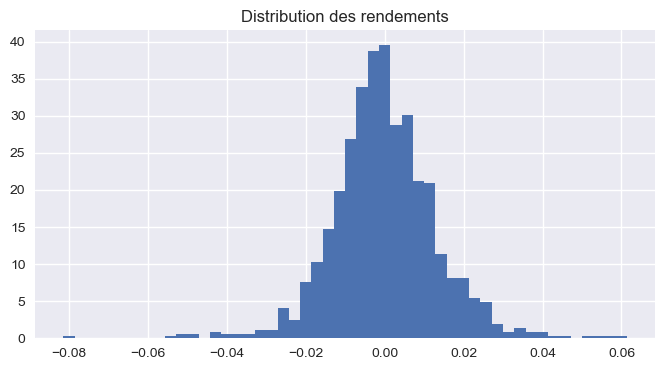

In [12]:
#ANALYSES DESCRIPTIVES
plt.figure(figsize=(8,4))
plt.hist(returns, bins=50, density=True)
plt.title("Distribution des rendements")
plt.show()

In [8]:
returns.describe()

count    1302.000000
mean       -0.000133
std         0.013089
min        -0.081357
25%        -0.007658
50%        -0.000670
75%         0.007074
max         0.061412
dtype: float64

In [10]:
print("Skewness :", skew(returns))
print("Kurtosis :", kurtosis(returns))

Skewness : -0.03212861860261264
Kurtosis : 2.934582458735517


1. En Python : kurtosis(returns) renvoie l’excès de kurtosis (kurtosis - 3).
Donc : Kurtosis_total =2.93+3=5.93 => K>3

→ distribution leptokurtique
→ queues épaisses
→ justification claire de la TVE

2. Skewness ≈ -0.03 → quasi symétrique
✔ pas d’asymétrie marquée


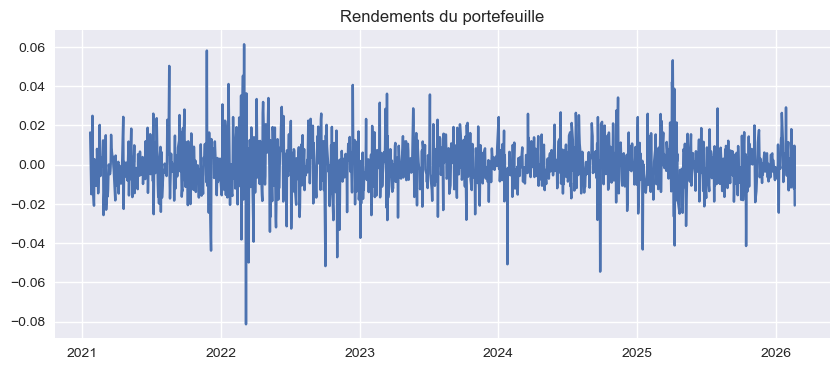

In [13]:
# VERIFICATION HETEROSCEDASTICITE
plt.figure(figsize=(10,4))
plt.plot(returns)
plt.title("Rendements du portefeuille")
plt.show()

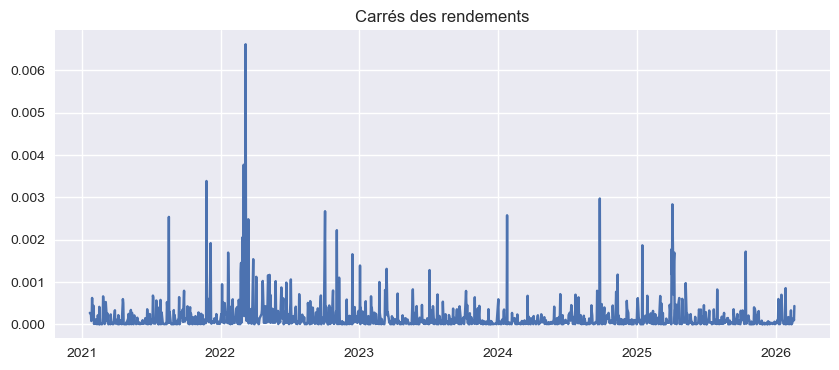

In [14]:
plt.figure(figsize=(10,4))
plt.plot(returns**2)
plt.title("Carrés des rendements")
plt.show()

3. Volatilité conditionnelle ?
- Le graphique des carrés montre clairement : pics regroupés, périodes calmes, périodes agitées => Clustering de volatilité.
Donc :
- hypothèse iid discutable
- GARCH justifié
- TVE-GARCH pertinent

CONCLUSION: Les rendements présentent une kurtosis supérieure à 3, indiquant la présence de queues épaisses. 
De plus, l’analyse des carrés des rendements met en évidence un phénomène de clustering de volatilité, suggérant la présence d’hétéroscédasticité conditionnelle.
Ces éléments justifient l’utilisation d’une approche par Théorie des Valeurs Extrêmes (TVE) ainsi que son extension conditionnelle via un modèle GARCH.

4️. PARTIE I — TVE (POT)
4.1. Rappel théorique
......................
D’après le théorème de Pickands–Balkema–de Haan, les excès au-dessus d’un seuil élevé u suivent asymptotiquement une loi de Pareto généralisée GPD(ξ, β). On définit les excès : Y = L - u | L > u
La VaR s’écrit : VaR_α = u + (β/ξ)[((n/N_u)(1-α))^{-ξ} - 1]

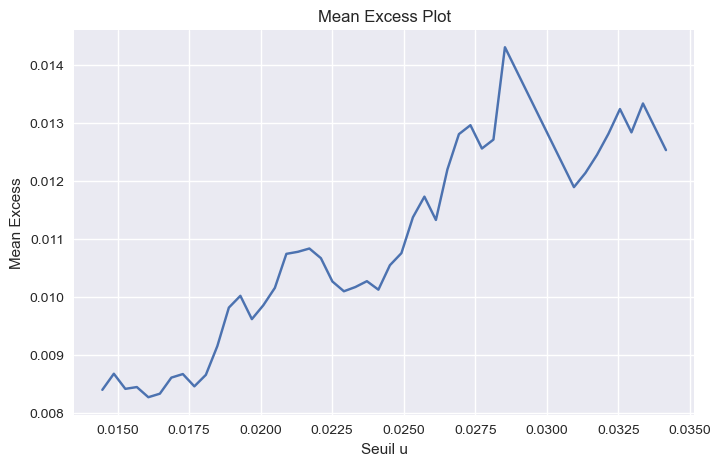

In [16]:
# 4.2. CHOIX DU SEUIL
def mean_excess(data, thresholds):
    mean_excess_values = []
    for u in thresholds:
        excess = data[data > u] - u
        mean_excess_values.append(excess.mean())
    return mean_excess_values

thresholds = np.linspace(losses.quantile(0.90),
                         losses.quantile(0.99),
                         50)

me_values = mean_excess(losses, thresholds)

plt.figure(figsize=(8,5))
plt.plot(thresholds, me_values)
plt.xlabel("Seuil u")
plt.ylabel("Mean Excess")
plt.title("Mean Excess Plot")
plt.show()

In [18]:
# On examine plusieurs seuils candidats
candidate_quantiles = [0.94, 0.95, 0.96, 0.97]

for q in candidate_quantiles:
    u = losses.quantile(q)
    Nu = len(losses[losses > u])
    print(f"Quantile {q} → seuil {u:.5f} → excès {Nu} ({Nu/len(losses):.2%})")

Quantile 0.94 → seuil 0.01830 → excès 79 (6.07%)
Quantile 0.95 → seuil 0.01911 → excès 66 (5.07%)
Quantile 0.96 → seuil 0.02078 → excès 53 (4.07%)
Quantile 0.97 → seuil 0.02400 → excès 40 (3.07%)


Le choix du seuil repose sur un compromis biais-variance.
- Un seuil trop faible viole l’approximation asymptotique de la GPD.
- Un seuil trop élevé réduit excessivement le nombre d’excès, rendant l’estimation instable.
- Le quantile 95% (u ≈ 1.91%) génère 66 observations extrêmes, soit environ 5% de l’échantillon, ce qui constitue un compromis
satisfaisant entre validité asymptotique et stabilité statistique.

In [19]:
threshold = losses.quantile(0.95)

In [20]:
excess = losses[losses > threshold] - threshold

In [27]:
# 4.3 Estimation GPD (MLE)
xi, loc, beta = genpareto.fit(excess)

params = pd.DataFrame({
    "Paramètre": ["xi (forme)", "beta (échelle)"],
    "Valeur": [xi, beta]
})

params

,Paramètre,Valeur
0,xi (forme),0.455763
1,beta (échelle),0.006636


Les paramètres ξ (forme) et β (échelle) sont estimés
par maximum de vraisemblance.

Interprétation :
- ξ > 0 : queues épaisses
- ξ = 0 : exponentielle
- ξ < 0 : borne supérieure finie
- L’estimation par maximum de vraisemblance conduit à :
ξ ≈ 0.456  
β ≈ 0.0066  
- La valeur positive de ξ indique la présence de queues épaisses, ce qui est cohérent avec la littérature financière.
- Par ailleurs, ξ < 0.5 implique l’existence d’une variance finie, garantissant la stabilité statistique du modèle.
- β mesure la dispersion des excès. Il est cohérent avec : seuil ≈ 1.9% et excès moyens autour de 0.5% à 1%

In [30]:
# 4.4 Calcul de la VaR TVE à 99%
# Nombre total d'observations
n = len(losses)

# Nombre d'excès
Nu = len(excess)

alpha = 0.99

VaR_evt = threshold + (beta/xi) * (((n/Nu)*(1-alpha))**(-xi) - 1)

print(f"VaR TVE à 99% : {VaR_evt:.4%}")

VaR TVE à 99% : 3.5061%


La VaR est calculée au niveau de confiance 99% afin de se concentrer sur les pertes rares et sévères.

La théorie des valeurs extrêmes étant asymptotique, elle est particulièrement adaptée à l’estimation de quantiles élevés, correspondant aux événements
de faible probabilité (1% ou moins).

Un niveau plus faible (ex. 95%) ne correspondrait
pas à une véritable analyse des extrêmes.

In [32]:
# Calcul de la VaR normale à 99%
from scipy.stats import norm

mu = returns.mean()
sigma = returns.std()

VaR_norm = -(mu + sigma * norm.ppf(0.01))

print(f"VaR Normale à 99% : {VaR_norm:.4%}")

VaR Normale à 99% : 3.0582%


La VaR estimée via la TVE (3.51%) est supérieure à celle obtenue sous l’hypothèse de normalité (3.06%).

Ce résultat confirme que la loi normale sous-estime le risque extrême en présence de queues épaisses.

L’approche TVE permet ainsi une meilleure estimation des pertes rares, conformément aux propriétés théoriques du paramètre ξ > 0.

5️. PARTIE II — TVE-GARCH
Les rendements financiers présentent une volatilité conditionnelle.
L'hypothèse iid de la TVE peut être violée.

On filtre donc la dynamique de volatilité via un modèle GARCH(1,1) avant d'appliquer la TVE aux résidus standardisés.

In [34]:
#5.1 Estimation GARCH(1,1) : On travaille sur les rendements
model = arch_model(100*returns, vol='Garch', p=1, q=1)

res = model.fit(disp="off")

print(res.summary())

                     Constant Mean - GARCH Model Results                      
Dep. Variable:                   None   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -2148.61
Distribution:                  Normal   AIC:                           4305.21
Method:            Maximum Likelihood   BIC:                           4325.90
                                        No. Observations:                 1302
Date:                Tue, Mar 03 2026   Df Residuals:                     1301
Time:                        18:07:33   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu            -0.0398  3.486e-02     -1.143      0.253 [ -0.108,

Les paramètres estimés sont :
α ≈ 0.11  
β ≈ 0.77  
La somme α + β ≈ 0.88 confirme une forte persistance de la volatilité conditionnelle, caractéristique des séries financières.
Le modèle GARCH(1,1) semble donc adapté pour capturer le phénomène de clustering observé précédemment.

In [36]:
#5.2 Extraction des Résidus standardisés
std_resid = res.resid / res.conditional_volatility
std_resid = std_resid.dropna()

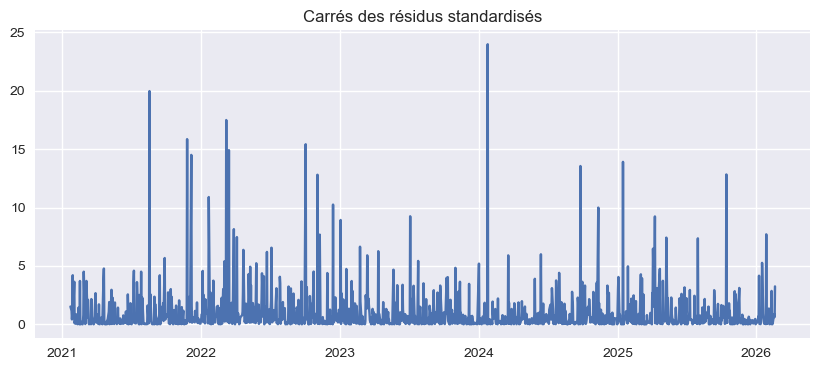

In [37]:
#Visualisation
plt.figure(figsize=(10,4))
plt.plot(std_resid**2)
plt.title("Carrés des résidus standardisés")
plt.show()

In [38]:
#5.3 TVE sur résidus

Z_losses = -std_resid # on travaille sur la queue gauche

# CHOIX DU SEUIL
threshold_z = Z_losses.quantile(0.95)

excess_z = Z_losses[Z_losses > threshold_z] - threshold_z

n_z = len(Z_losses)
Nu_z = len(excess_z)

print("Excès :", Nu_z)
print("Proportion :", Nu_z/n_z)

Excès : 66
Proportion : 0.05069124423963134


In [40]:
# Estimation de la GPD sur les résidus standardisés
xi_z, loc_z, beta_z = genpareto.fit(excess_z)

print(f"xi (résidus) : {xi_z:.4f}")
print(f"beta (résidus) : {beta_z:.4f}")

xi (résidus) : 0.1094
beta (résidus) : 0.6381


L'estimation de la GPD sur les résidus standardisés conduit à :
- ξ ≈ 0.109  
- β ≈ 0.638  
La valeur du paramètre de forme est nettement plus faibleque celle obtenue sur les rendements bruts (ξ ≈ 0.456).

Cela indique que le modèle GARCH capte une partie des extrêmes observés dans les rendements, en modélisant la volatilité conditionnelle.

Après filtrage de la volatilité, les queues de distribution apparaissent moins épaisses, ce qui est cohérent avec la littérature financière.

In [41]:
#5.4 VaR TVE-GARCH 
alpha = 0.99
VaR_z = threshold_z + (beta_z/xi_z) * (((n_z/Nu_z)*(1-alpha))**(-xi_z) - 1)

In [42]:
sigma_next = res.conditional_volatility.iloc[-1]
mu_next = res.params['mu']

In [45]:
VaR_tve_garch = abs((mu_next + sigma_next * VaR_z) / 100)

print(f"VaR TVE-GARCH à 99% : {VaR_tve_garch:.4%}")

VaR TVE-GARCH à 99% : 3.6075%


La VaR obtenue par la méthode TVE-GARCH est de 3.61%, ce qui est légèrement supérieur aux estimations
obtenues avec la loi normale (3.06%) et la TVE simple (3.51%).

Cette différence s'explique par la prise en compte de la volatilité conditionnelle via le modèle GARCH, qui capture le phénomène de clustering de volatilité observé dans les séries financières.

La méthode TVE-GARCH apparaît ainsi comme l'approche la plus robuste pour l'estimation du risque extrême du portefeuille.

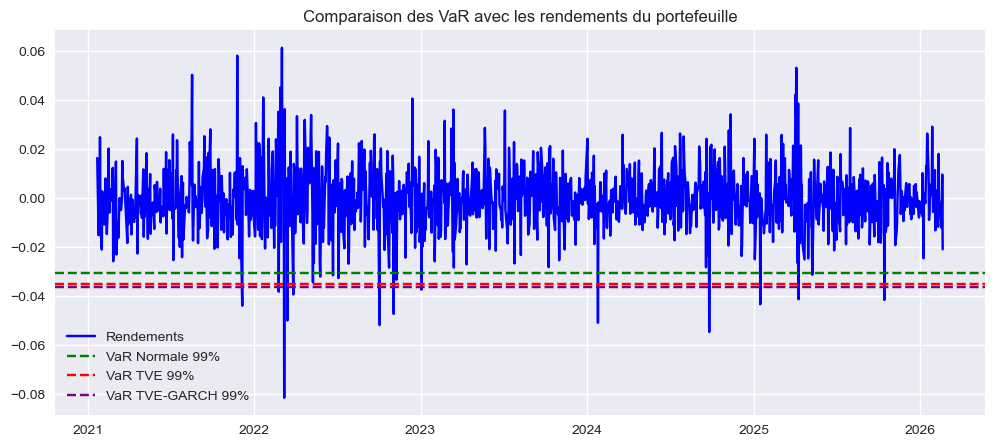

In [46]:
#6️. Graphique : Rendements vs VaR
#L’idée est de montrer quand les pertes dépassent la VaR. Les lignes représentent les seuils de perte maximale attendue avec 99% de confiance.
#Quand les rendements passent sous ces lignes, on parle de : Violation de VaR

plt.figure(figsize=(12,5))

plt.plot(returns.index, returns, label="Rendements", color="blue")

plt.axhline(-VaR_norm, color="green", linestyle="--", label="VaR Normale 99%")
plt.axhline(-VaR_evt, color="red", linestyle="--", label="VaR TVE 99%")
plt.axhline(-VaR_tve_garch, color="purple", linestyle="--", label="VaR TVE-GARCH 99%")

plt.title("Comparaison des VaR avec les rendements du portefeuille")
plt.legend()
plt.show()

Le graphique compare les rendements du portefeuille avec les estimations de VaR obtenues par différentes méthodes.

On observe que la VaR basée sur l'hypothèse de normalité est la moins prudente et sous-estime les pertes extrêmes.

La méthode TVE fournit une estimation plus élevée, car elle modélise explicitement les queues de distribution.

La méthode TVE-GARCH donne la VaR la plus conservatrice, car elle combine la modélisation de la volatilité conditionnelle avec la théorie des valeurs extrêmes.

In [47]:
# VaR dynamique TVE-GARCH

sigma_t = res.conditional_volatility
mu = res.params['mu']

VaR_dynamic = -(mu + sigma_t * VaR_z) / 100

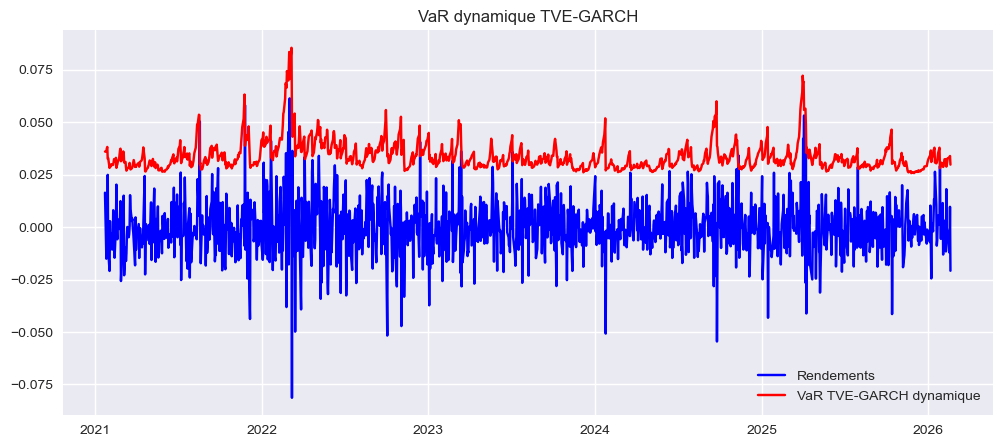

In [48]:
plt.figure(figsize=(12,5))

plt.plot(returns.index, returns, label="Rendements", color="blue")
plt.plot(returns.index, -VaR_dynamic, color="red", label="VaR TVE-GARCH dynamique")

plt.title("VaR dynamique TVE-GARCH")
plt.legend()
plt.show()

Le graphique présente la VaR dynamique estimée par la méthode TVE-GARCH.

Contrairement à une VaR statique, la VaR dynamique évolue dans le temps en fonction de la volatilité conditionnelle estimée par le modèle GARCH.

On observe que la VaR augmente lors des périodes de forte volatilité, ce qui permet une meilleure prise en compte du risque de marché.

Cette approche est plus réaliste car elle adapte le niveau de risque aux conditions de marché.

In [49]:
VaR_results = pd.DataFrame({
    "Méthode": ["Normale", "TVE", "TVE-GARCH"],
    "VaR 99%": [VaR_norm, VaR_evt, VaR_tve_garch]
})

VaR_results

,Méthode,VaR 99%
0,Normale,0.030582
1,TVE,0.035061
2,TVE-GARCH,0.036075
